In [ ]:
# -*- coding: utf-8 -*-
"""Food_Classifier_TransferLearning.ipynb
Transfer Learning version of Food Classifier (EfficientNet_B0)
Fixes: hardcoded model_0 bug, wrong dataloader length bug, overfitting
"""

# ── 1. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os, random, zipfile
import requests
from pathlib import Path
from PIL import Image
from typing import Tuple, Dict, List
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score


In [ ]:
# ── 2. Download & Unzip Data ──────────────────────────────────────────────────
data_path  = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if not image_path.is_dir():
    image_path.mkdir(parents=True, exist_ok=True)
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get(
            "https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip"
        )
        print("Downloading data...")
        f.write(request.content)
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping data...")
        zip_ref.extractall(image_path)
else:
    print(f"{image_path} already exists.")

train_dir = image_path / "train"
test_dir  = image_path / "test"

Unzipping data...


In [ ]:
# ── 3. Check Data ─────────────────────────────────────────────────────────────
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"  {len(dirnames)} dirs | {len(filenames)} images  →  {dirpath}")

walk_through_dir(image_path)


# ── 4. Transfer Learning Transforms (EfficientNet_B0 expects 224x224) ─────────
weights         = models.EfficientNet_B0_Weights.DEFAULT
auto_transforms = weights.transforms()   # handles resize + normalize automatically

print(f"\nAuto transforms: {auto_transforms}")


# ── 5. Datasets & DataLoaders ─────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = os.cpu_count()

train_data = datasets.ImageFolder(root=train_dir, transform=auto_transforms)
test_data  = datasets.ImageFolder(root=test_dir,  transform=auto_transforms)

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=NUM_WORKERS)
test_dataloader  = DataLoader(test_data,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)

class_names = train_data.classes
print(f"\nClasses: {class_names}")
print(f"Train samples: {len(train_data)} | Test samples: {len(test_data)}")



  2 dirs | 0 images  →  data/pizza_steak_sushi
  3 dirs | 0 images  →  data/pizza_steak_sushi/train
  0 dirs | 75 images  →  data/pizza_steak_sushi/train/steak
  0 dirs | 78 images  →  data/pizza_steak_sushi/train/pizza
  0 dirs | 72 images  →  data/pizza_steak_sushi/train/sushi
  3 dirs | 0 images  →  data/pizza_steak_sushi/test
  0 dirs | 19 images  →  data/pizza_steak_sushi/test/steak
  0 dirs | 25 images  →  data/pizza_steak_sushi/test/pizza
  0 dirs | 31 images  →  data/pizza_steak_sushi/test/sushi

Auto transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

Classes: ['pizza', 'steak', 'sushi']
Train samples: 225 | Test samples: 75


In [ ]:
# ── 6. Build Transfer Learning Model ─────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")

# Load pretrained EfficientNet_B0
model = models.efficientnet_b0(weights=weights)

# Freeze ALL base layers — we only train the new head
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head for our 3 classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names))
)

model = model.to(device)
print(f"\nModel head: {model.classifier}")



Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 191MB/s]



Model head: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


In [ ]:
# ── 7. Loss & Optimizer ───────────────────────────────────────────────────────
loss_fn   = nn.CrossEntropyLoss()
# Only pass classifier params — base is frozen, no point updating it
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)


# ── 8. Train Step ─────────────────────────────────────────────────────────────
def train_step(model: nn.Module,
               dataloader: DataLoader,
               loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
               device=device):
    model.train()
    train_loss, train_acc = 0, 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)                          # ✅ uses passed-in model, not hardcoded
        loss   = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc   += accuracy_score(y.cpu().numpy(), y_pred_class.cpu().numpy())

    train_loss /= len(dataloader)                  # ✅ divides by correct dataloader
    train_acc  /= len(dataloader)
    return train_loss, train_acc





In [ ]:
# ── 9. Test Step ──────────────────────────────────────────────────────────────
def test_step(model: nn.Module,
              dataloader: DataLoader,
              loss_fn: nn.Module,
              device=device):
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            y_logits = model(X)                    # ✅ uses passed-in model
            loss      = loss_fn(y_logits, y)
            test_loss += loss.item()

            y_pred_class = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
            test_acc    += accuracy_score(y.cpu().numpy(), y_pred_class.cpu().numpy())

    test_loss /= len(dataloader)                   # ✅ divides by correct dataloader
    test_acc  /= len(dataloader)
    return test_loss, test_acc



In [ ]:
# ── 10. Full Training Loop ────────────────────────────────────────────────────
def train(model: nn.Module,
          train_dataloader: DataLoader,
          test_dataloader: DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 10):

    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer)
        test_loss,  test_acc  = test_step( model, test_dataloader,  loss_fn)

        print(f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
              f"test_loss: {test_loss:.4f}  | test_acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [ ]:
# ── 11. Run Training ──────────────────────────────────────────────────────────
import time
start = time.time()

results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=10)           # 10 epochs is enough for transfer learning

print(f"\nTotal training time: {time.time() - start:.3f}s")




  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0530 | train_acc: 0.4023 | test_loss: 0.8500  | test_acc: 0.7623
Epoch: 2 | train_loss: 0.9151 | train_acc: 0.6328 | test_loss: 0.7093  | test_acc: 0.8750
Epoch: 3 | train_loss: 0.7760 | train_acc: 0.8438 | test_loss: 0.7022  | test_acc: 0.8854
Epoch: 4 | train_loss: 0.7049 | train_acc: 0.7695 | test_loss: 0.6871  | test_acc: 0.8447
Epoch: 5 | train_loss: 0.6417 | train_acc: 0.7773 | test_loss: 0.6402  | test_acc: 0.8447
Epoch: 6 | train_loss: 0.5629 | train_acc: 0.8281 | test_loss: 0.5785  | test_acc: 0.8551
Epoch: 7 | train_loss: 0.5056 | train_acc: 0.9492 | test_loss: 0.5303  | test_acc: 0.8854
Epoch: 8 | train_loss: 0.5065 | train_acc: 0.9219 | test_loss: 0.5346  | test_acc: 0.8248
Epoch: 9 | train_loss: 0.4552 | train_acc: 0.9336 | test_loss: 0.5041  | test_acc: 0.8958
Epoch: 10 | train_loss: 0.5083 | train_acc: 0.8242 | test_loss: 0.4961  | test_acc: 0.8655

Total training time: 22.202s


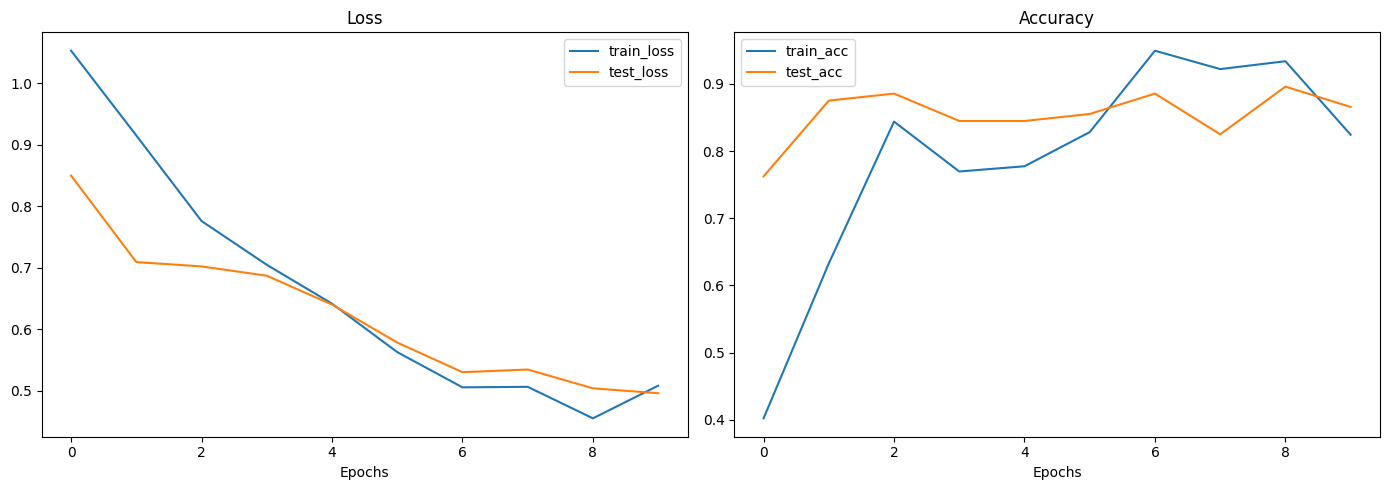

In [ ]:
 #── 12. Plot Results ──────────────────────────────────────────────────────────
def plot_loss_curves(results: dict):
    epochs = range(len(results["train_loss"]))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, results["train_loss"], label="train_loss")
    ax1.plot(epochs, results["test_loss"],  label="test_loss")
    ax1.set_title("Loss"); ax1.set_xlabel("Epochs"); ax1.legend()

    ax2.plot(epochs, results["train_acc"], label="train_acc")
    ax2.plot(epochs, results["test_acc"],  label="test_acc")
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epochs"); ax2.legend()

    plt.tight_layout()
    plt.show()

plot_loss_curves(results)





In [ ]:
# ── 13. Predict on a Random Test Image ───────────────────────────────────────
def predict_image(model, image_path, transform, class_names, device=device):
    img = Image.open(image_path)
    img_tensor = transform(img).unsqueeze(0).to(device)  # add batch dim

    model.eval()
    with torch.inference_mode():
        logits     = model(img_tensor)
        pred_class = torch.argmax(torch.softmax(logits, dim=1), dim=1).item()

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_class]}")
    plt.axis(False)
    plt.show()
    return class_names[pred_class]



Predicting: data/pizza_steak_sushi/train/steak/2087958.jpg


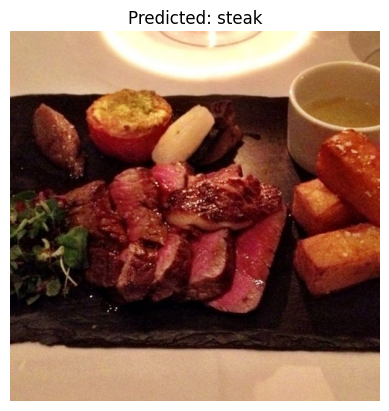

'steak'

In [ ]:
# Test on a random image
image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image    = random.choice(image_path_list)
print(f"\nPredicting: {random_image}")
predict_image(model, random_image, auto_transforms, class_names)